In [1]:
import os

import matplotlib.pyplot as plt
import torch
import traceback

import numpy

from classifier import *
import random

from collections import Counter

In [2]:
print("cwd", os.getcwd())

cwd C:\Beryllium Base\WORKSPACES\MTECH\dl-vehicles\experiments


In [22]:
try:
    classifier = VehicleClassifier(fop('temp\\model_state_space.pth'))
except:
    traceback.print_exc()

motorcycle


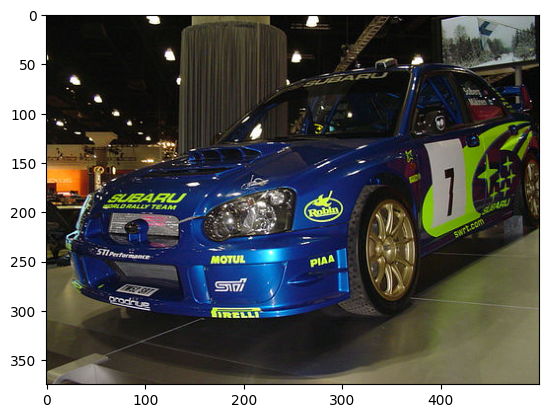

In [48]:
def predict(self, image_path: str) -> int:
    image = Image.open(image_path).convert("RGB")
    tensor = self.transform(image).unsqueeze(0).to(self.device)
    with torch.no_grad():
        classification, discrimination = self.model(tensor)
        discrimination = discrimination > 1
        return (classification.argmax(axis=1) * discrimination + 4 * (not discrimination)).item()


try:
    in_root = r'..\dataset\imagenet'
    mapping = random.choice(os.listdir(in_root))
    sample = random.choice(os.listdir(os.path.join(in_root, mapping)))
    path = os.path.join(in_root, mapping, sample)
    plt.imshow(Image.open(path))
    idx = predict(classifier, path)

    if idx == 4: print("none")
    else: print(idx_to_class[idx])
except:
    traceback.print_exc()